# Wind Turbine Blade Damage Detection — YOLOv8 fine-tuning

Dataset: WTBD (Ji, Cheng & Wu, *Scientific Data* 13:396, 2026).

**After a Colab restart:** run cells 1-4, then jump to "Write data.yaml".
The slow conversion cells only need to run once, ever.


## 1. Install and authenticate

In [ ]:
!pip install -q ultralytics==8.3.40 huggingface_hub

In [1]:
import os

# Token stored as a Colab secret (key icon, left sidebar, name it HF_TOKEN
# and enable notebook access). Survives runtime restarts, and nothing
# sensitive ends up in the notebook committed to Git.
try:
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
except Exception:
    from huggingface_hub import notebook_login
    notebook_login()

from huggingface_hub import HfApi, whoami

api = HfApi()
print("logged in as:", whoami()["name"])

logged in as: OAoussama


## 2. Mount Drive

Training runs are written to Drive so a disconnect does not destroy two hours of work.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

PROJECT = "/content/drive/MyDrive/blade-runs"
DATASET_REPO = "OAoussama/blade-inspection-dataset"
MODEL_REPO = "OAoussama/yolo8v"
YOLO_ROOT = "/content/yolo_dataset"

Mounted at /content/drive


## 3. Restore the prepared dataset (fast path)

If `yolo_dataset.zip` already exists on the Hub, this is a single download
instead of 3,200 individual file requests. Run the conversion section below
only the first time.

In [ ]:
from huggingface_hub import hf_hub_download

DATASET_READY = False
try:
    zip_path = hf_hub_download(DATASET_REPO, "yolo_dataset.zip", repo_type="dataset")
    !unzip -qo {zip_path} -d /content
    DATASET_READY = os.path.isdir(f"{YOLO_ROOT}/images/train")
    print("dataset restored from zip:", DATASET_READY)
except Exception as exc:
    print("zip not available — run the conversion section once:", exc)

zip not available — run the conversion section once: 404 Client Error. (Request ID: Root=1-6aaad79c-598f91975bf866c35bbc8ee2;85174d21-dd16-4c7d-a7af-ac4a66c91b7c)

Entry Not Found for url: https://huggingface.co/datasets/OAoussama/blade-inspection-dataset/resolve/main/yolo_dataset.zip.


## 4. First-time only — download, convert, split

Skip this whole section when cell 3 printed `True`.

In [ ]:
from huggingface_hub import snapshot_download

# annotation_second_person/ is the second annotator's labels, used in the
# paper for inter-annotator agreement. Thousands of tiny XML files that are
# not needed for training and that trigger HTTP 429 rate limiting.
DATASET_DIR = snapshot_download(
    repo_id=DATASET_REPO,
    repo_type="dataset",
    local_dir="/content/dataset",
    ignore_patterns=["annotation_second_person/*"],
)
print("Dataset downloaded to:", DATASET_DIR)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2135 files:   0%|          | 0/2135 [00:00<?, ?it/s]

Dataset downloaded to: /content/dataset


In [ ]:
import xml.etree.ElementTree as ET
from collections import Counter

IMG_DIR = os.path.join(DATASET_DIR, "JPEGImages")
XML_DIR = os.path.join(DATASET_DIR, "Annotations")
CLASS_FILE = os.path.join(DATASET_DIR, "class_definitions.txt")
LABELS_DIR = os.path.join(DATASET_DIR, "labels_yolo")

# One class name per line; line position = YOLO class id (0-indexed).
with open(CLASS_FILE) as f:
    names_list = [line.strip() for line in f if line.strip()]

name_to_id = {name: i for i, name in enumerate(names_list)}
os.makedirs(LABELS_DIR, exist_ok=True)

instance_counts = Counter()
converted = 0

for xml_file in os.listdir(XML_DIR):
    if not xml_file.endswith(".xml"):
        continue

    root = ET.parse(os.path.join(XML_DIR, xml_file)).getroot()
    size = root.find("size")
    img_w, img_h = int(size.find("width").text), int(size.find("height").text)

    lines = []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        instance_counts[name] += 1
        cls_id = name_to_id[name]

        b = obj.find("bndbox")
        xmin, ymin = float(b.find("xmin").text), float(b.find("ymin").text)
        xmax, ymax = float(b.find("xmax").text), float(b.find("ymax").text)

        # YOLO wants centre coordinates + size, normalised 0-1.
        lines.append(
            f"{cls_id} "
            f"{((xmin + xmax) / 2) / img_w:.6f} "
            f"{((ymin + ymax) / 2) / img_h:.6f} "
            f"{(xmax - xmin) / img_w:.6f} "
            f"{(ymax - ymin) / img_h:.6f}"
        )

    stem = os.path.splitext(xml_file)[0]
    with open(os.path.join(LABELS_DIR, f"{stem}.txt"), "w") as f:
        f.write("\n".join(lines))
    converted += 1

print(f"Converted {converted} annotation files.")
print("Class mapping:", name_to_id)
print("Instances per class:", dict(instance_counts))

Converted 1065 annotation files.
Class mapping: {'craze': 0, 'corrosion': 1, 'surface_injure': 2, 'thunderstrike': 3, 'crack': 4, 'hide_craze': 5}
Instances per class: {'craze': 257, 'crack': 224, 'corrosion': 257, 'hide_craze': 342, 'surface_injure': 412, 'thunderstrike': 92}


In [ ]:
import csv
import shutil

SPLIT_FILE = os.path.join(DATASET_DIR, "train_val_test_split.txt")

for split in ("train", "val", "test"):
    os.makedirs(f"{YOLO_ROOT}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_ROOT}/labels/{split}", exist_ok=True)

counts = Counter()
with open(SPLIT_FILE) as f:
    for row in csv.DictReader(f):
        image_id, split = row["ImageID"], row["Subset"]
        stem = os.path.splitext(image_id)[0]

        shutil.copy(os.path.join(IMG_DIR, image_id), f"{YOLO_ROOT}/images/{split}/{image_id}")

        src = os.path.join(LABELS_DIR, f"{stem}.txt")
        dst = f"{YOLO_ROOT}/labels/{split}/{stem}.txt"
        if os.path.exists(src):
            shutil.copy(src, dst)
        else:
            open(dst, "w").close()  # background image, no objects

        counts[split] += 1

print("Images per split:", dict(counts))

Images per split: {'val': 159, 'train': 745, 'test': 161}


In [ ]:
# Upload the prepared dataset as a single archive, so future sessions use
# the fast path in cell 3.
!cd /content && zip -qr yolo_dataset.zip yolo_dataset

api.upload_file(
    path_or_fileobj="/content/yolo_dataset.zip",
    path_in_repo="yolo_dataset.zip",
    repo_id=DATASET_REPO,
    repo_type="dataset",
)
print("uploaded yolo_dataset.zip")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/yolo_dataset.zip   :   1%|          |  524kB / 76.8MB            

uploaded yolo_dataset.zip


## 5. Write data.yaml

The class order here **must** match the converter's `name_to_id`. If the two
ever diverge, every prediction is silently mislabelled.

In [ ]:
import yaml

CLASS_NAMES = ["craze", "corrosion", "surface_injure", "thunderstrike", "crack", "hide_craze"]

# If the conversion cells ran in this session, trust them over the hardcoded list.
if "names_list" in globals():
    CLASS_NAMES = names_list

data_yaml = {
    "path": YOLO_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}

with open("data.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(open("data.yaml").read())

path: /content/yolo_dataset
train: images/train
val: images/val
test: images/test
nc: 6
names:
- craze
- corrosion
- surface_injure
- thunderstrike
- crack
- hide_craze



## 6. Train

`project` points at Drive, and `save_period=10` writes a checkpoint every
10 epochs — a disconnect costs minutes, not the whole run.

In [ ]:
from ultralytics import YOLO

RUN_NAME = "train100"

model = YOLO("yolov8s.pt")
model.train(
    data="data.yaml",
    epochs=100,
    imgsz=1024,          # cracks are thin; 640 loses them in 4K drone photos
    seed=42,             # reproducible — you will be asked about this
    project=PROJECT,
    name=RUN_NAME,
    patience=30,
    batch=-1,            # auto-sized to the GPU
    save_period=10,
)

RUN_DIR = str(model.trainer.save_dir)
print("run dir:", RUN_DIR)

New https://pypi.org/project/ultralytics/8.4.154 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=data.yaml, epochs=100, time=None, patience=30, batch=-1, imgsz=1024, save=True, save_period=10, cache=False, device=None, workers=8, project=/content/drive/MyDrive/blade-runs, name=train100, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=



100%|██████████| 755k/755k [00:00<00:00, 24.1MB/s]


Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 119MB/s]


AMP: checks passed ✅


...

    100/100      7.55G     0.8136      0.612      1.182          6       1024: 100%|██████████| 58/58 [00:32<00:00,  1.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.30it/s]

                   all        159        246      0.827      0.772      0.817      0.521



100 epochs completed in 1.078 hours.
Optimizer stripped from /content/drive/MyDrive/blade-runs/train100/weights/last.pt, 22.6MB
Optimizer stripped from /content/drive/MyDrive/blade-runs/train100/weights/best.pt, 22.6MB

Validating /content/drive/MyDrive/blade-runs/train100/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:06<00:00,  1.07it/s]


                   all        159        246      0.815      0.778      0.823      0.522
                 craze         29         43      0.944      0.884      0.936      0.618
             corrosion         23         29      0.764      0.724      0.773      0.388
        surface_injure         45         80      0.859      0.812      0.872      0.604
         thunderstrike         12         13      0.708      0.692      0.683      0.437
                 crack         31         44      0.977      0.959      0.993      0.623
            hide_craze         31         37      0.638      0.595      0.683      0.463
Speed: 0.6ms preprocess, 12.8ms inference, 0.0ms loss, 9.6ms postprocess per image
Results saved to /content/drive/MyDrive/blade-runs/train100
run dir: /content/drive/MyDrive/blade-runs/train100


### Resume after a disconnect

Run this cell **instead of** the one above if the session dropped mid-training.

In [ ]:
# RUN_DIR = f"{PROJECT}/train100"
# model = YOLO(f"{RUN_DIR}/weights/last.pt")
# model.train(resume=True)

## 7. Results

results.png


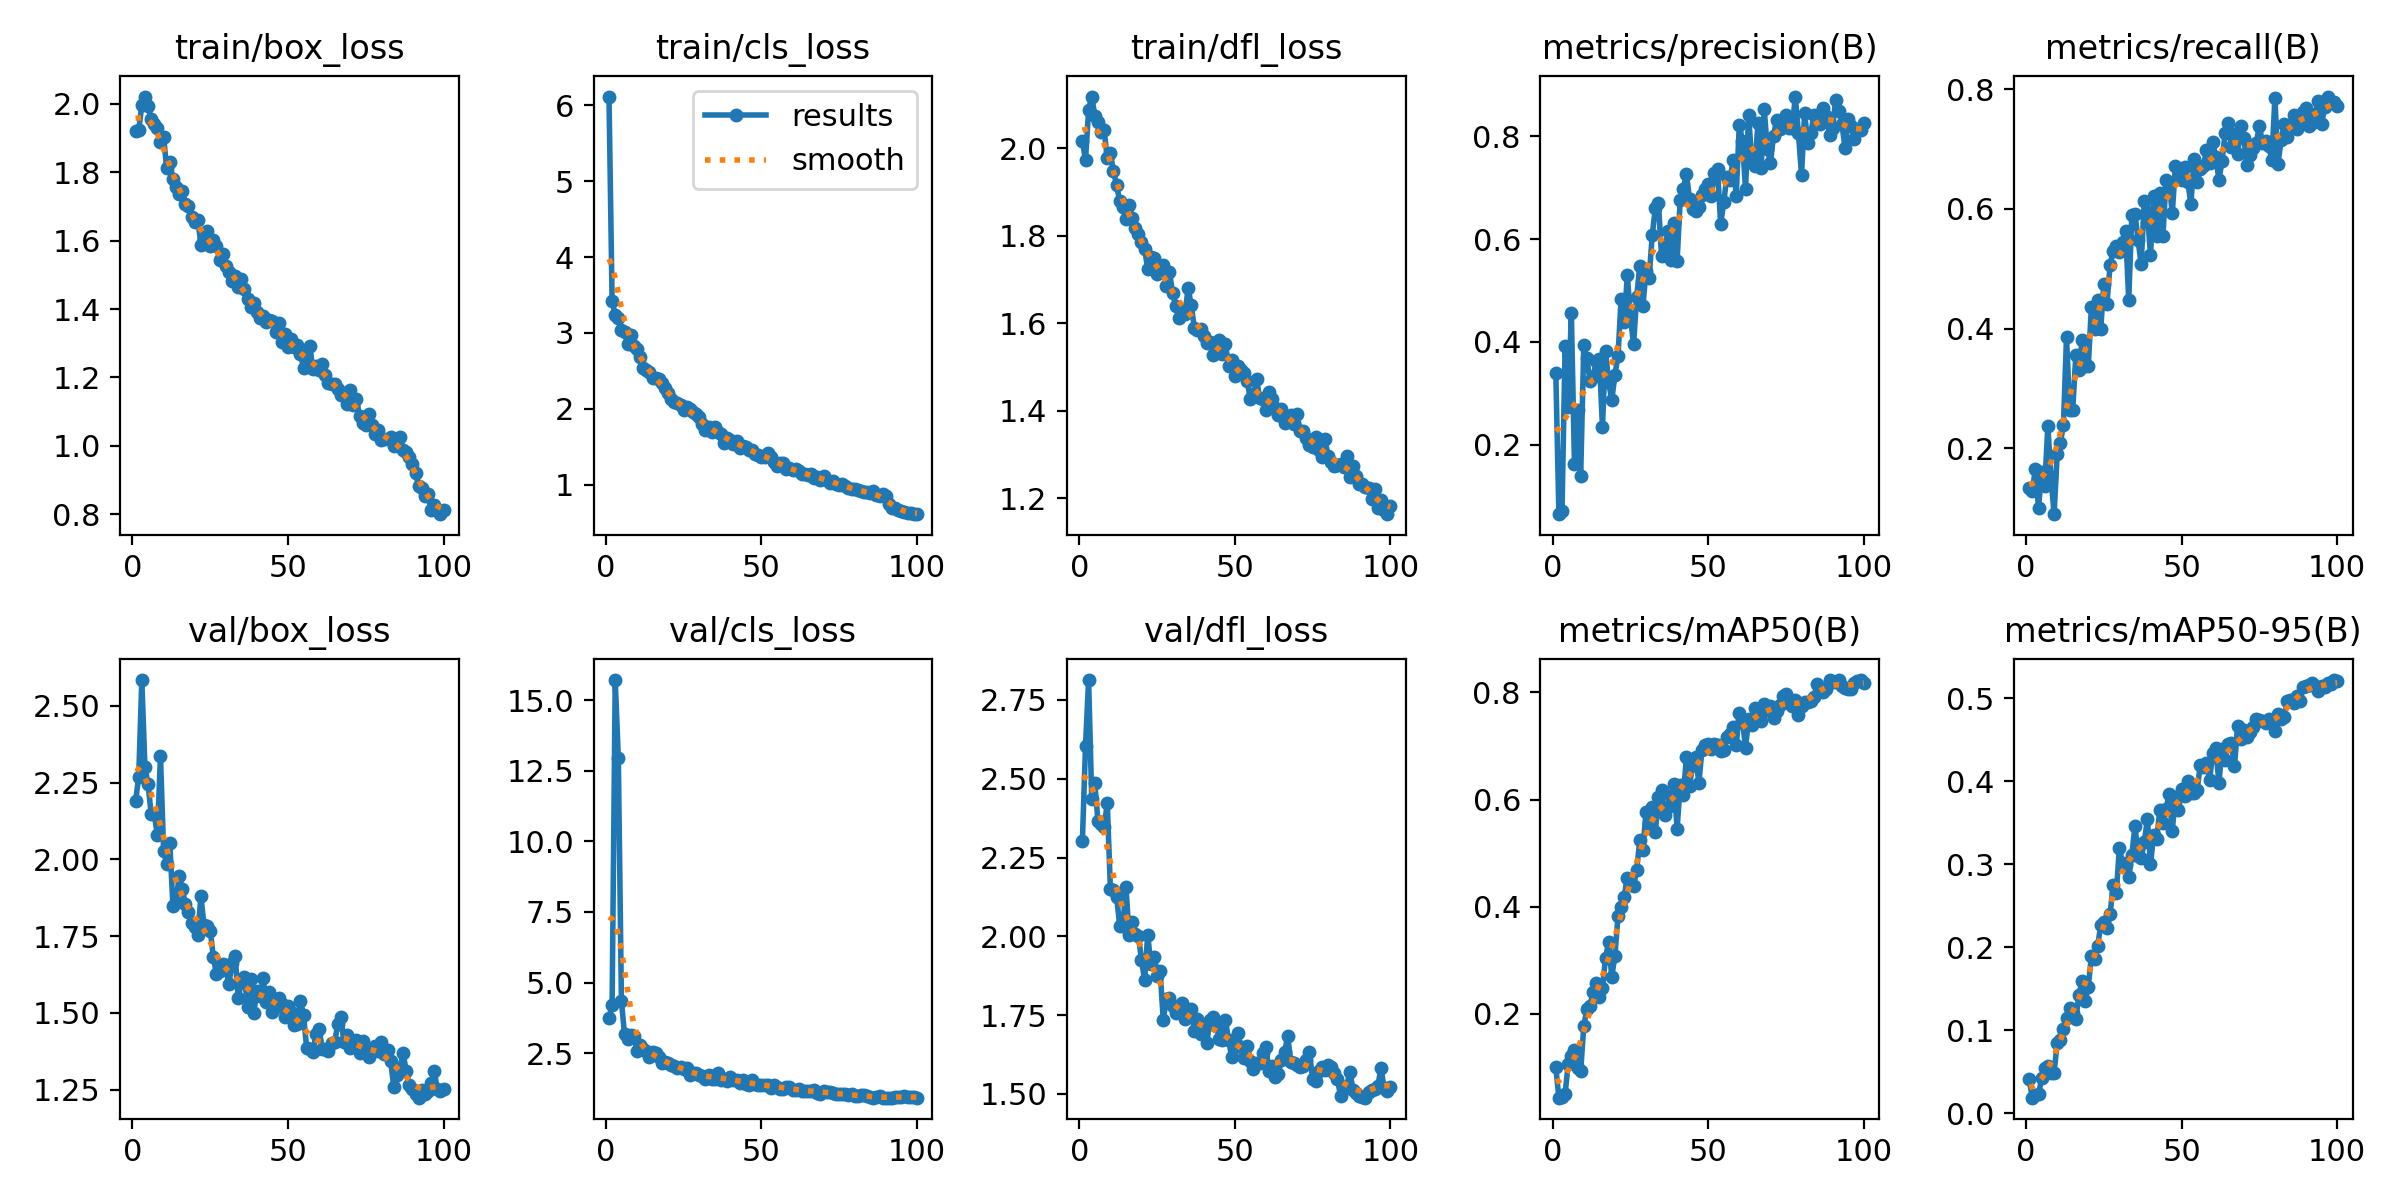

confusion_matrix.png


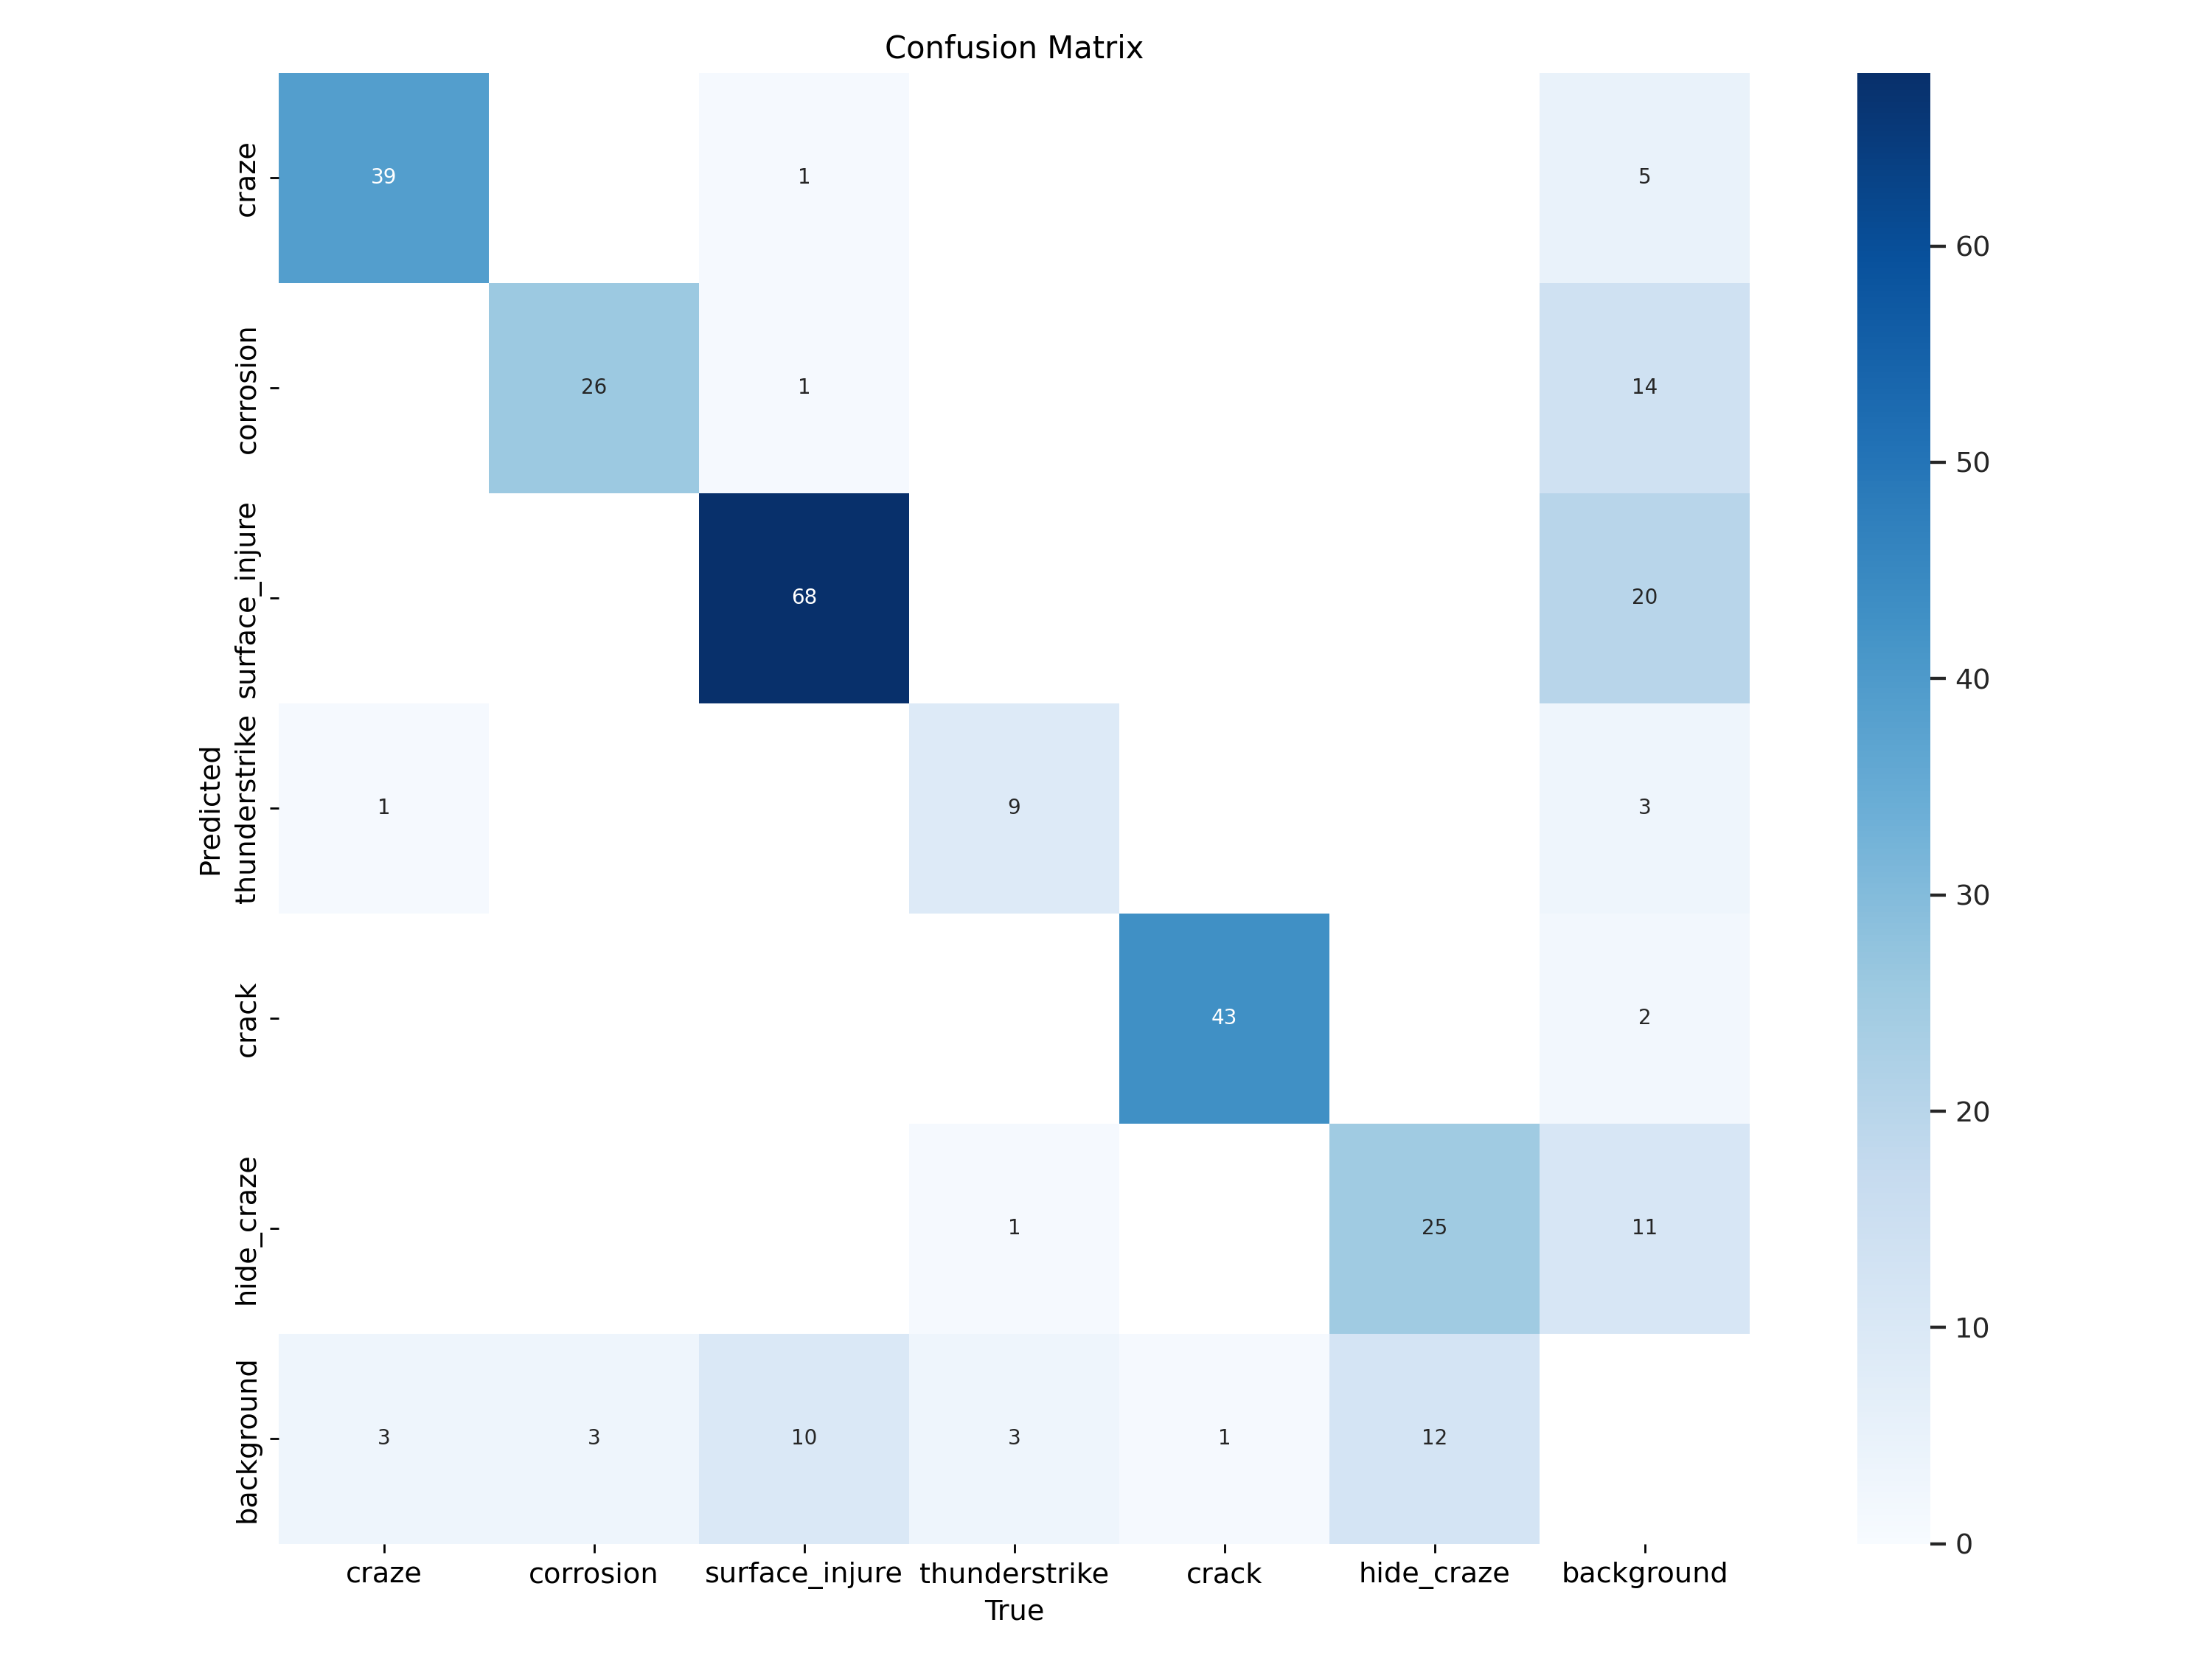

confusion_matrix_normalized.png


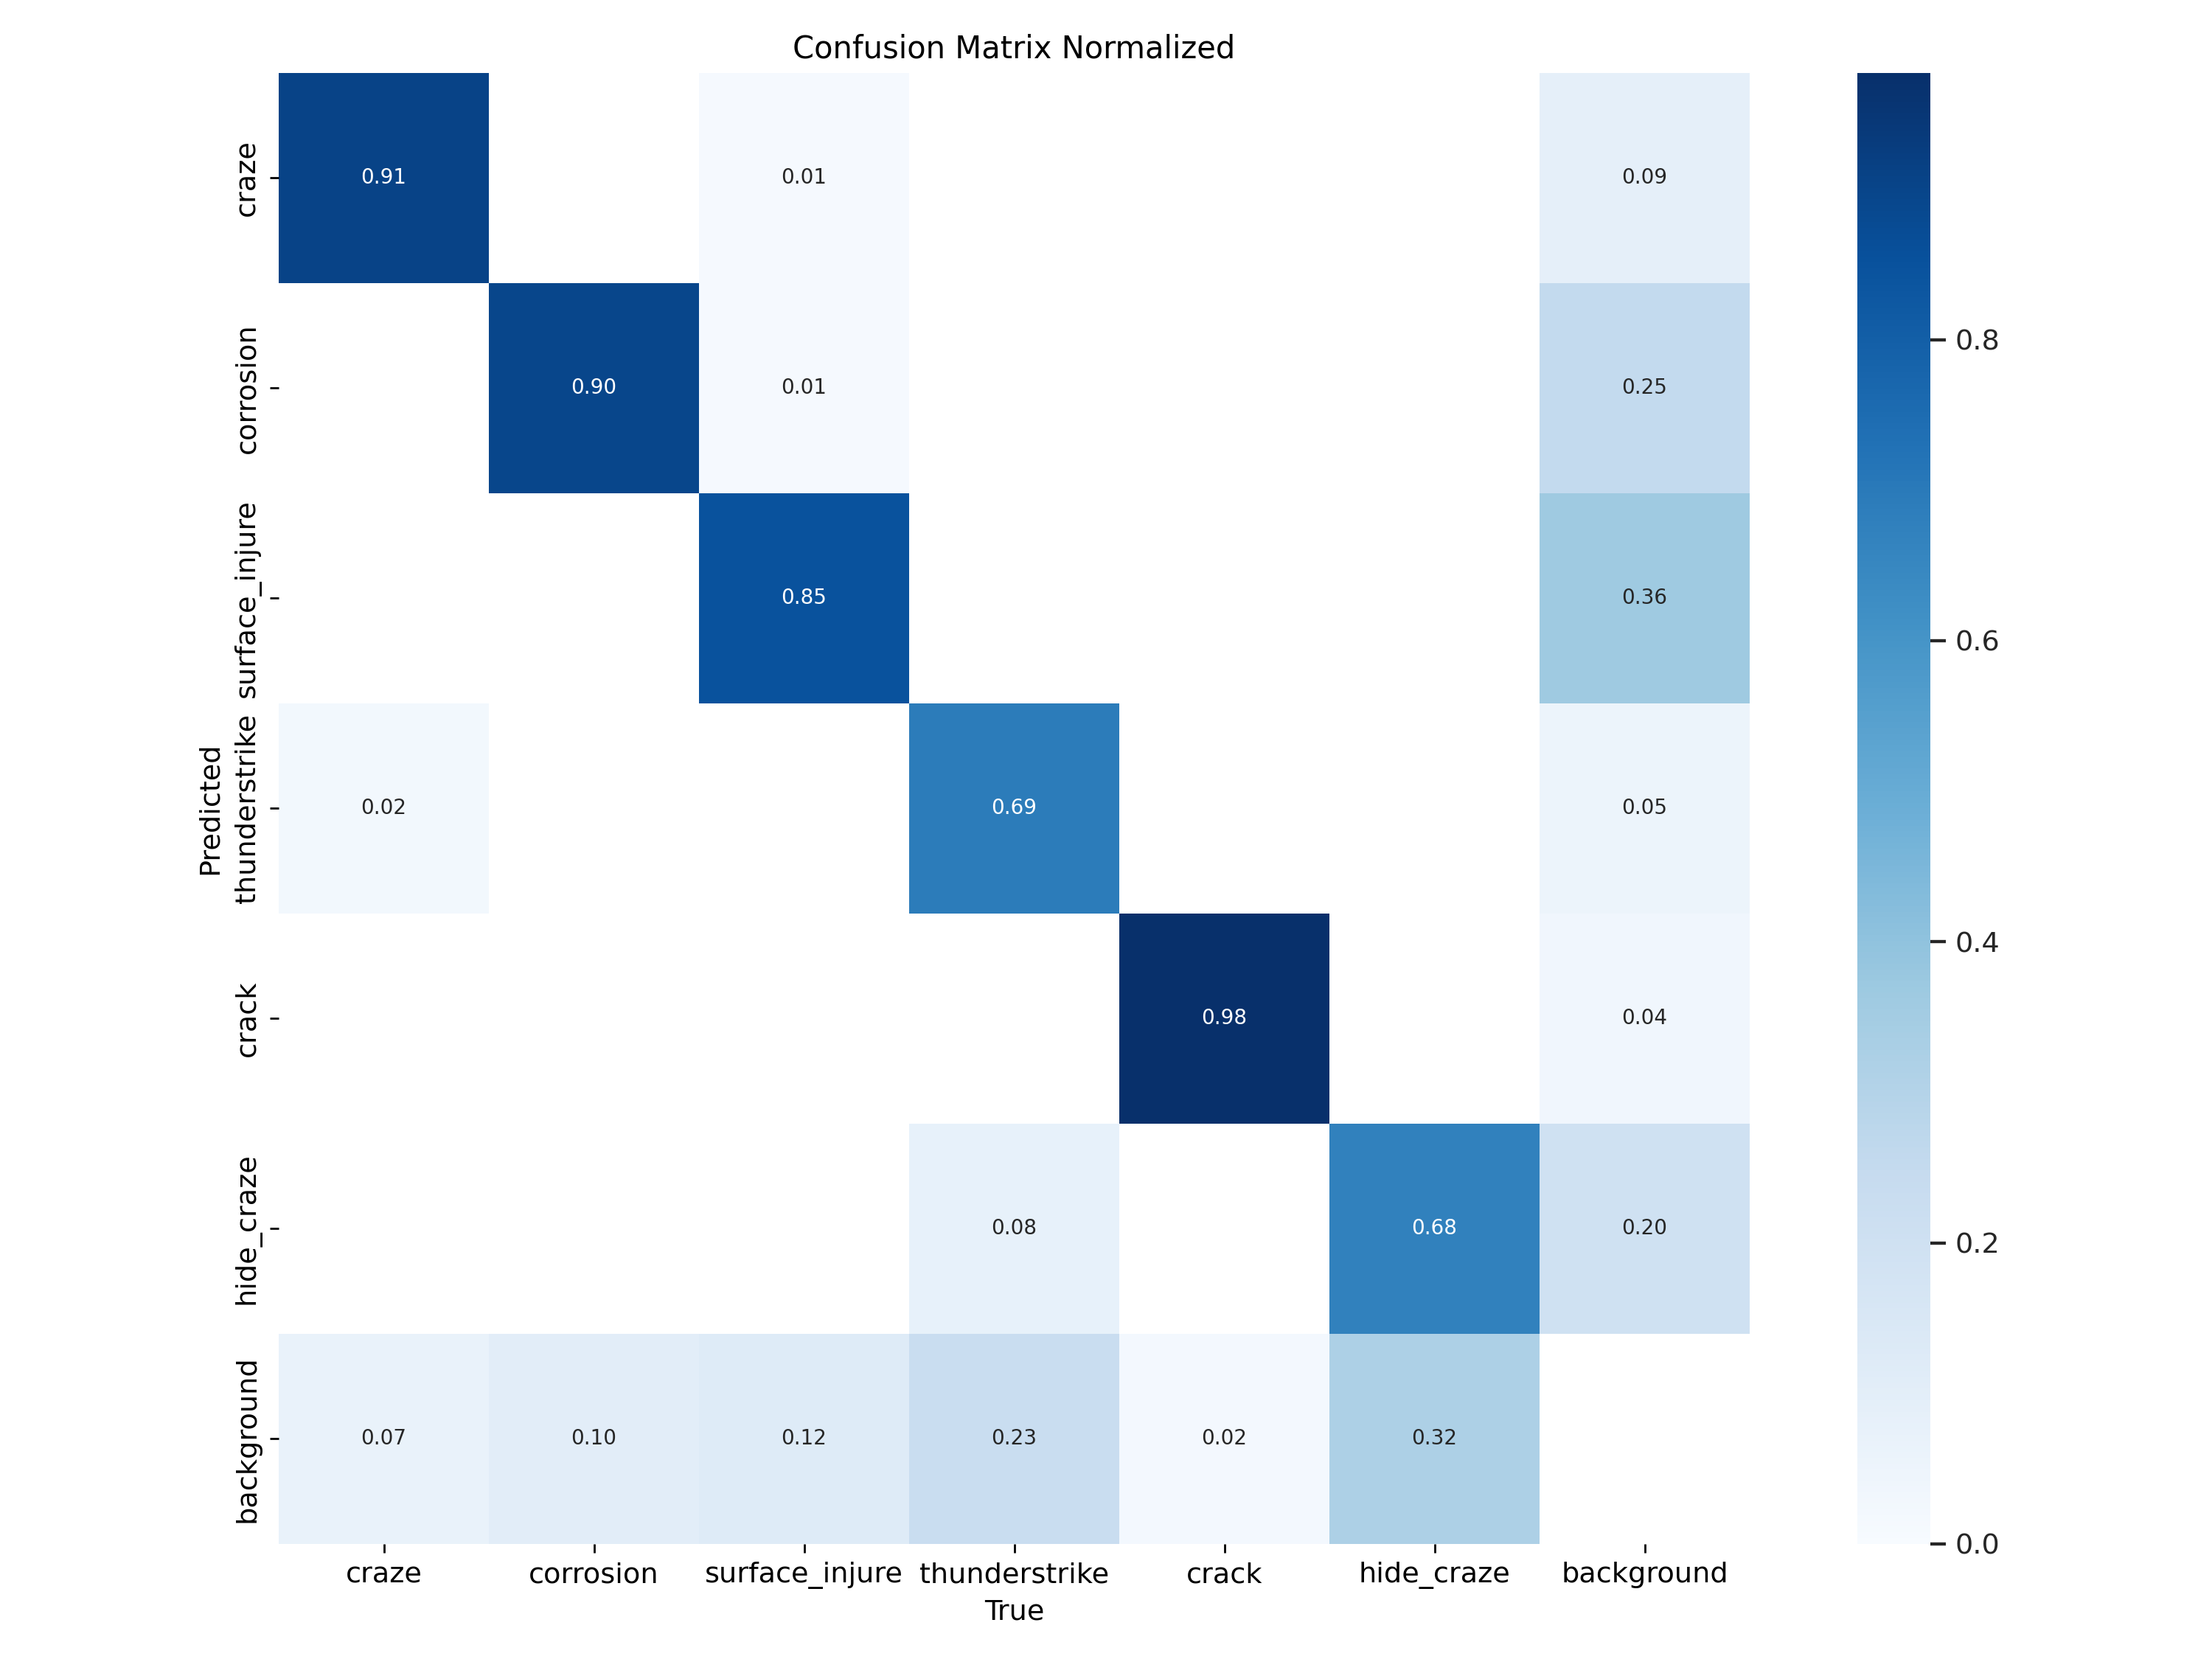

In [ ]:
from IPython.display import Image, display

for plot in ("results.png", "confusion_matrix.png", "confusion_matrix_normalized.png"):
    path = f"{RUN_DIR}/{plot}"
    if os.path.exists(path):
        print(plot)
        display(Image(filename=path))

### Per-class metrics on the held-out test set

Report **test** numbers, not validation. The validation set guided training
(best.pt was selected on it), so its metrics are optimistic.

In [ ]:
metrics = model.val(data="data.yaml", split="test")

print(f"{'class':18s} {'P':>7s} {'R':>7s} {'mAP50':>7s} {'mAP50-95':>9s}")
print("-" * 52)
for i, c in enumerate(metrics.ap_class_index):
    p, r, ap50, ap = metrics.box.class_result(i)
    print(f"{metrics.names[c]:18s} {p:7.3f} {r:7.3f} {ap50:7.3f} {ap:9.3f}")

print("-" * 52)
print(
    f"{'all':18s} {metrics.box.mp:7.3f} {metrics.box.mr:7.3f} "
    f"{metrics.box.map50:7.3f} {metrics.box.map:9.3f}"
)

Ultralytics 8.3.40 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs


val: Scanning /content/yolo_dataset/labels/test... 161 images, 0 backgrounds, 0 corrupt: 100%|██████████| 161/161 [00:00<00:00, 444.54it/s]

val: New cache created: /content/yolo_dataset/labels/test.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:07<00:00,  1.66it/s]


                   all        161        238      0.852      0.756      0.805      0.503
                 craze         29         38      0.725      0.711      0.709      0.414
             corrosion         32         46      0.748       0.58      0.661      0.317
        surface_injure         37         53      0.835      0.766      0.786      0.561
         thunderstrike         16         17          1      0.959      0.995      0.661
                 crack         23         31      0.933      0.839      0.953      0.619
            hide_craze         39         53      0.871      0.679      0.728      0.448
Speed: 0.8ms preprocess, 25.4ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to /content/drive/MyDrive/blade-runs/train1002
class                    P       R   mAP50  mAP50-95
----------------------------------------------------
craze                0.725   0.711   0.709     0.414
corrosion            0.748   0.580   0.661     0.317
surface_injure       

## 8. Publish the weights

Upload, then tag. The tag is what the FastAPI backend pins with
`revision=`, so a later retrain cannot silently change what the API returns.

In [ ]:
TAG = "v2"   # v1 = the 50-epoch run

api.create_repo(repo_id=MODEL_REPO, exist_ok=True)
api.upload_file(
    path_or_fileobj=f"{RUN_DIR}/weights/best.pt",
    path_in_repo="best.pt",
    repo_id=MODEL_REPO,
)
api.create_tag(repo_id=MODEL_REPO, tag=TAG, revision="main")
print(f"pushed and tagged {TAG}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  .../train100/weights/best.pt:   2%|2         |  529kB / 22.6MB            

pushed and tagged v2


### Model card

Weights without a model card are unusable by anyone else, including future you.

In [ ]:
card = f"""---
license: cc-by-4.0
tags:
  - object-detection
  - yolov8
  - wind-turbine
---

# Wind turbine blade damage detection — YOLOv8s

Fine-tuned from `yolov8s.pt` (COCO) on the WTBD dataset.

## Classes

{", ".join(CLASS_NAMES)}

Class indices are stored in the checkpoint as `model.names` — read them from
there rather than hardcoding, so a reordered `data.yaml` cannot mislabel
predictions.

## Training

- 100 epochs, imgsz=1024, seed=42, batch auto
- Ultralytics 8.3.40

## Metrics (held-out test split)

mAP50: {metrics.box.map50:.3f} — mAP50-95: {metrics.box.map:.3f}

## Data source

Ji, L., Cheng, J., Wu, S. *Multiclass Dataset for Intelligent Detection of
Wind Turbine Blade Defects Using Drone Imagery.* Scientific Data 13, 396 (2026).
https://doi.org/10.1038/s41597-026-06762-x
"""

open("README.md", "w").write(card)
api.upload_file(
    path_or_fileobj="README.md",
    path_in_repo="README.md",
    repo_id=MODEL_REPO,
)
print(card)

---
license: cc-by-4.0
tags:
  - object-detection
  - yolov8
  - wind-turbine
---

# Wind turbine blade damage detection — YOLOv8s

Fine-tuned from `yolov8s.pt` (COCO) on the WTBD dataset.

## Classes

craze, corrosion, surface_injure, thunderstrike, crack, hide_craze

Class indices are stored in the checkpoint as `model.names` — read them from
there rather than hardcoding, so a reordered `data.yaml` cannot mislabel
predictions.

## Training

- 100 epochs, imgsz=1024, seed=42, batch auto
- Ultralytics 8.3.40

## Metrics (held-out test split)

mAP50: 0.805 — mAP50-95: 0.503

## Data source

Ji, L., Cheng, J., Wu, S. *Multiclass Dataset for Intelligent Detection of
Wind Turbine Blade Defects Using Drone Imagery.* Scientific Data 13, 396 (2026).
https://doi.org/10.1038/s41597-026-06762-x

